In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
df=pd.read_csv('INPUT.csv')

In [103]:
df.head()

,DateTime,Date,Heure,Valeur,SPOT,MA,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso
0,2024-01-01,00:00:00,2024-01-01,00:00:00,19.49,197.27,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,52800.0
1,2024-01-01,00:30:00,2024-01-01,00:00:00,19.49,206.63,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,53000.0
2,2024-01-01,01:00:00,2024-01-01,01:00:00,16.12,23.62,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,47200.0
3,2024-01-01,01:30:00,2024-01-01,01:00:00,16.12,56.66,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,48100.0
4,2024-01-01,02:00:00,2024-01-01,02:00:00,0.06,10.68,171.5,893.5,8.0,95.0,-842.5,2459.0,502.5,18660.0,0.0,43.5,6894.5,49800.0


In [104]:
df.shape

(17544, 18)

In [105]:
df.dropna().shape

(17471, 18)

In [106]:
df=df.dropna()

In [107]:
df.columns

Index(['DateTime', 'Date', 'Heure', 'Valeur', 'SPOT', 'MA', 'BIOMASS',
       'FOSSIL_GAS', 'FOSSIL_HARD_COAL', 'FOSSIL_OIL', 'HYDRO_PUMPED_STORAGE',
       'HYDRO_RUN_OF_RIVER', 'HYDRO_WATER_RESERVOIR', 'NUCLEAR', 'SOLAR',
       'WASTE', 'WIND_ONSHORE', 'conso'],
      dtype='object')

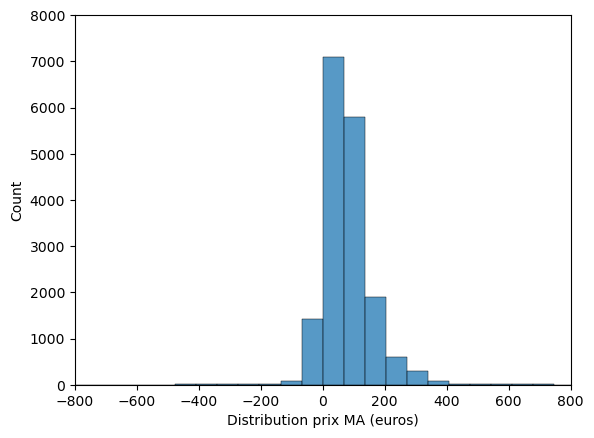

In [108]:
sns.histplot(df['MA'], bins=100)
plt.xlim(-800, 800)   # limite l'axe x
plt.ylim(0, 8000)    # limite l'axe y
plt.xlabel("Distribution prix MA (euros)")
plt.show()

In [109]:
df['MA'].describe()

count    17471.000000
mean        79.799059
std        112.157420
min      -2917.980000
25%         18.855000
50%         67.880000
75%        116.315000
max       3866.420000
Name: MA, dtype: float64

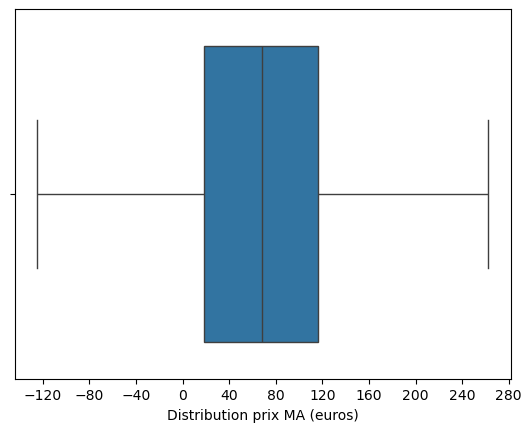

In [110]:
from matplotlib.ticker import MaxNLocator

sns.boxplot(data=df, x='MA',showfliers=False)
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=12))  # Jusqu'à 20 graduations
plt.xlabel("Distribution prix MA (euros)")
plt.show()


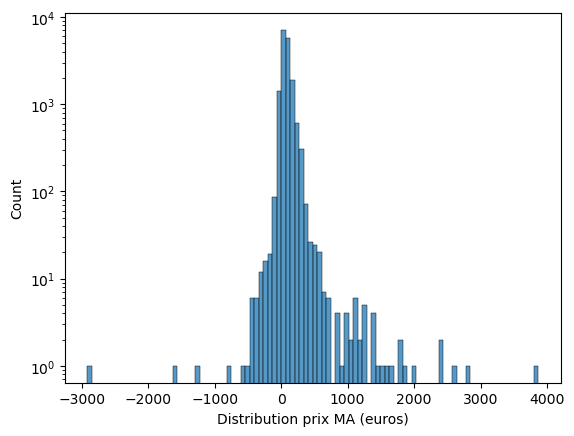

In [111]:
sns.histplot(df['MA'], bins=100)
plt.xlabel("Distribution prix MA (euros)")

plt.yscale('log')  # Pour voir les extrêmes

In [112]:
df.head()

,DateTime,Date,Heure,Valeur,SPOT,MA,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso
0,2024-01-01,00:00:00,2024-01-01,00:00:00,19.49,197.27,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,52800.0
1,2024-01-01,00:30:00,2024-01-01,00:00:00,19.49,206.63,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,53000.0
2,2024-01-01,01:00:00,2024-01-01,01:00:00,16.12,23.62,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,47200.0
3,2024-01-01,01:30:00,2024-01-01,01:00:00,16.12,56.66,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,48100.0
4,2024-01-01,02:00:00,2024-01-01,02:00:00,0.06,10.68,171.5,893.5,8.0,95.0,-842.5,2459.0,502.5,18660.0,0.0,43.5,6894.5,49800.0


### Production

In [ ]:
df.columns

Index(['DateTime', 'Date', 'Heure', 'Valeur', 'SPOT', 'MA', 'BIOMASS',
       'FOSSIL_GAS', 'FOSSIL_HARD_COAL', 'FOSSIL_OIL', 'HYDRO_PUMPED_STORAGE',
       'HYDRO_RUN_OF_RIVER', 'HYDRO_WATER_RESERVOIR', 'NUCLEAR', 'SOLAR',
       'WASTE', 'WIND_ONSHORE', 'conso', 'Total Production'],
      dtype='object')

In [120]:
df['Renouvelable']=df['BIOMASS']+df['HYDRO_PUMPED_STORAGE']+df['HYDRO_RUN_OF_RIVER']+df['HYDRO_WATER_RESERVOIR']+df['SOLAR']
df['Fossile']=df['FOSSIL_GAS']+df['FOSSIL_HARD_COAL']+df['FOSSIL_OIL']
df['Totale']=df['NUCLEAR']+df['Fossile']+df['Renouvelable']

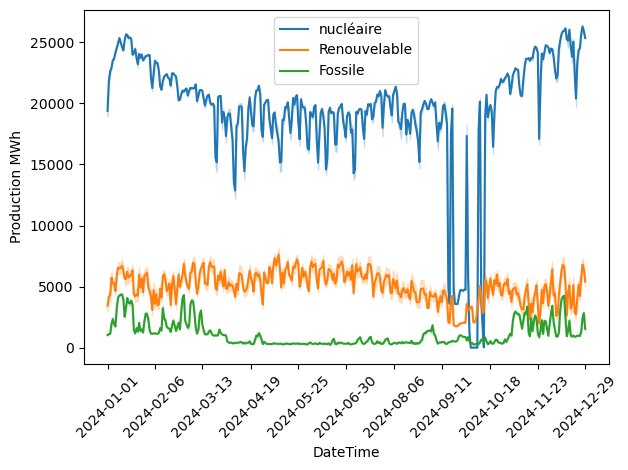

In [124]:
sns.lineplot(data=df, x='DateTime', y='NUCLEAR',label='nucléaire')
sns.lineplot(data=df, x='DateTime', y='Renouvelable',label='Renouvelable')   # kind: "scatter", "kde", "hex"
sns.lineplot(data=df, x='DateTime', y='Fossile',label='Fossile')   # kind: "scatter", "kde", "hex"
# sns.lineplot(data=df, x='DateTime', y='conso',label='Consommation')   # kind: "scatter", "kde", "hex"
# sns.lineplot(data=df, x='DateTime', y='Totale',label='Production Totale')   # kind: "scatter", "kde", "hex"



  # kind: "scatter", "kde", "hex"
# Sélectionner 10 valeurs régulièrement espacées pour l'axe x
x_ticks = df['DateTime'].iloc[::len(df)//10]  # Prendre 1 point tous les N/10

# Appliquer les ticks et éventuellement les faire pivoter pour une meilleure lisibilité
plt.xticks(x_ticks, rotation=45)
plt.ylabel('Production MWh')
plt.legend()
plt.tight_layout()  # Ajuster l'espacement
plt.show()

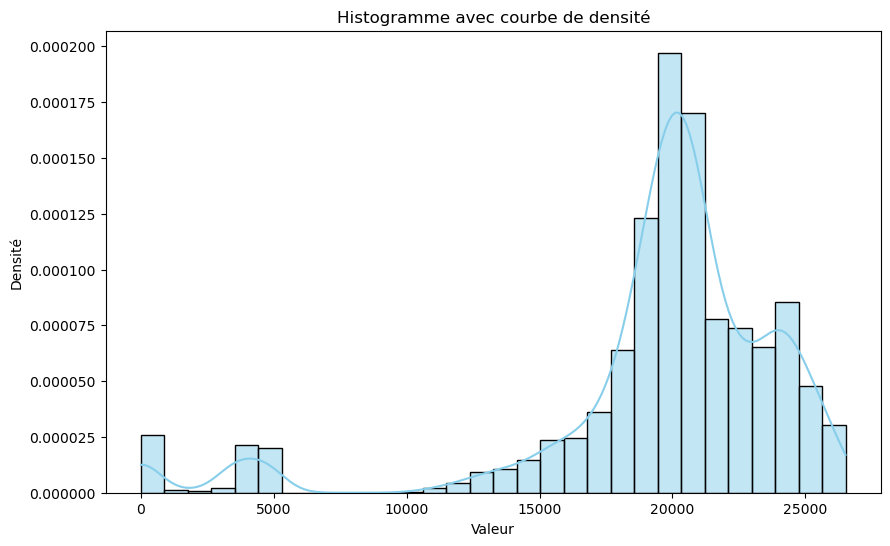

In [127]:
plt.figure(figsize=(10, 6))
sns.histplot(df['NUCLEAR'], kde=True, stat='density', color='skyblue', bins=30)
plt.title('Histogramme avec courbe de densité')
plt.xlabel('Valeur')
plt.ylabel('Densité')
plt.show()

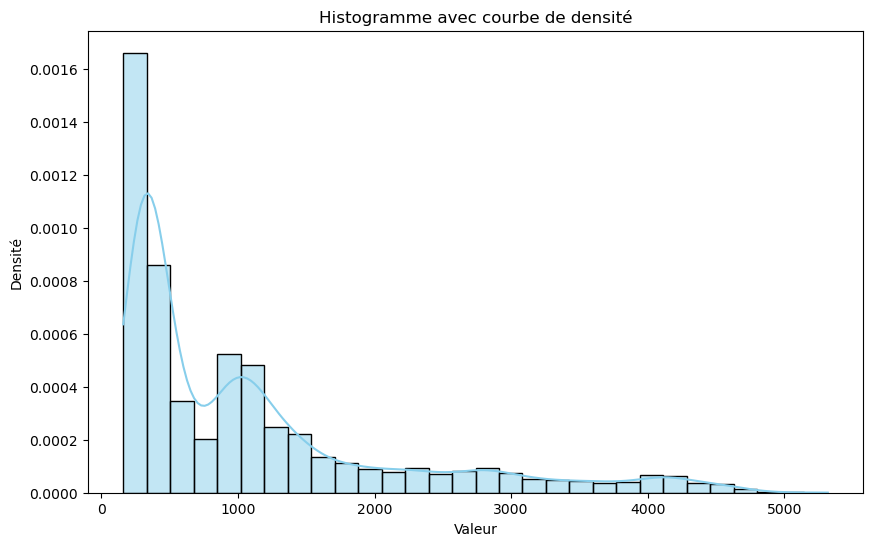

In [129]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fossile'], kde=True, stat='density', color='skyblue', bins=30)
plt.title('Histogramme avec courbe de densité')
plt.xlabel('Valeur')
plt.ylabel('Densité')
plt.show()

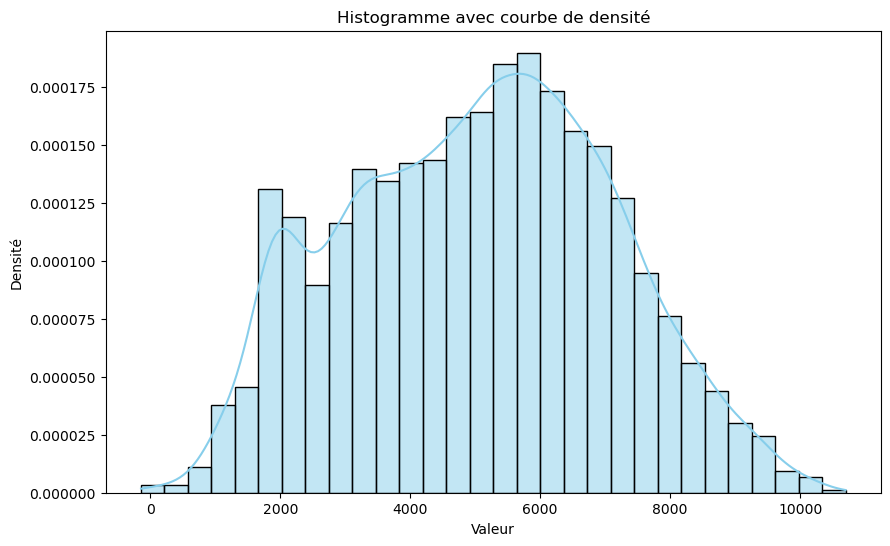

In [130]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Renouvelable'], kde=True, stat='density', color='skyblue', bins=30)
plt.title('Histogramme avec courbe de densité')
plt.xlabel('Valeur')
plt.ylabel('Densité')
plt.show()

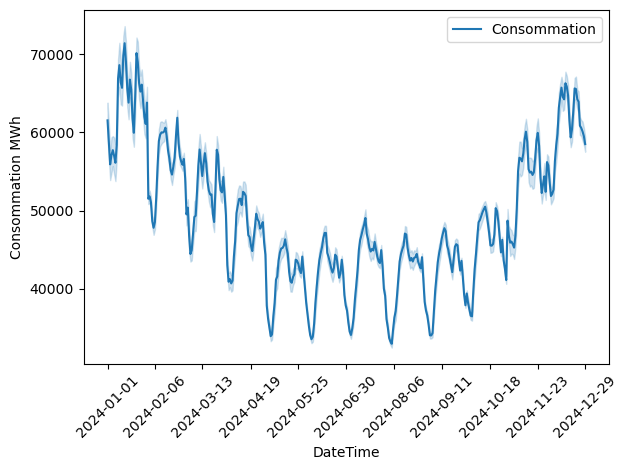

In [131]:
sns.lineplot(data=df, x='DateTime', y='conso',label='Consommation')
  # kind: "scatter", "kde", "hex"
# sns.lineplot(data=df, x='DateTime', y='conso',label='Consommation')   # kind: "scatter", "kde", "hex"
# sns.lineplot(data=df, x='DateTime', y='Totale',label='Production Totale')   # kind: "scatter", "kde", "hex"



  # kind: "scatter", "kde", "hex"
# Sélectionner 10 valeurs régulièrement espacées pour l'axe x
x_ticks = df['DateTime'].iloc[::len(df)//10]  # Prendre 1 point tous les N/10

# Appliquer les ticks et éventuellement les faire pivoter pour une meilleure lisibilité
plt.xticks(x_ticks, rotation=45)
plt.ylabel('Consommation MWh')
plt.legend()
plt.tight_layout()  # Ajuster l'espacement
plt.show()

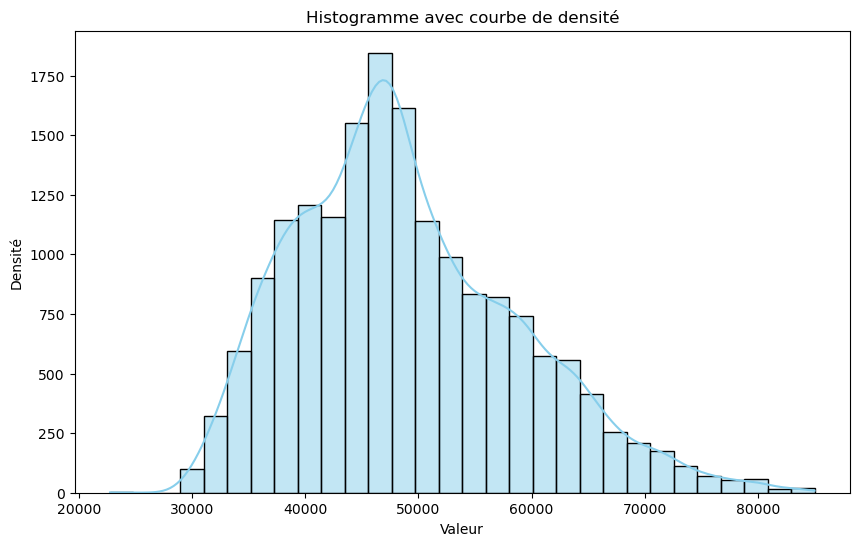

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['conso'], kde=True, color='skyblue', bins=30)
plt.title('Histogramme avec courbe de densité')
plt.xlabel('Valeur')
plt.ylabel('Consommation')
plt.show()

#### correlation

In [134]:
df.columns

Index(['DateTime', 'Date', 'Heure', 'Valeur', 'SPOT', 'MA', 'BIOMASS',
       'FOSSIL_GAS', 'FOSSIL_HARD_COAL', 'FOSSIL_OIL', 'HYDRO_PUMPED_STORAGE',
       'HYDRO_RUN_OF_RIVER', 'HYDRO_WATER_RESERVOIR', 'NUCLEAR', 'SOLAR',
       'WASTE', 'WIND_ONSHORE', 'conso', 'Renouvelable', 'Fossile', 'Totale'],
      dtype='object')

In [135]:
test=df[['MA','SPOT','NUCLEAR','Renouvelable','Fossile','conso']]

<Axes: >

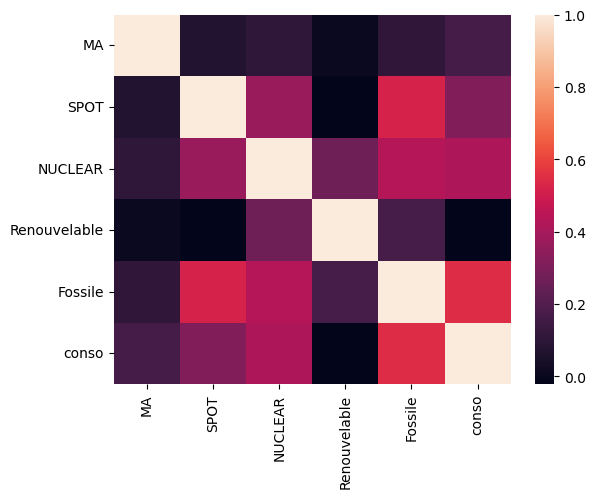

In [139]:
sns.heatmap(test.corr())